In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel('/Users/alevaldivia/Downloads/Lab_3/Motor Trend Car Road Tests.xlsx')
data.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [3]:
y = data['mpg']

In [4]:
data = data.drop(columns=['model'])

In [5]:
target_col = 'mpg'
numerical_cols = ['disp', 'hp', 'drat', 'wt', 'qsec']
categorical_cols = ['cyl', 'gear', 'carb']
boolean_cols = ['vs', 'am']

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [7]:
numerical_transformer = StandardScaler()

# En validación pueden aparecer categorías ausentes del entrenamiento.
# Se representan con ceros en las columnas de esa variable.
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols),
        ('bool', 'passthrough', boolean_cols)
    ],
    remainder='drop'
)

In [9]:
model = LinearRegression()

In [10]:
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ]
)

In [11]:
X = data.drop(columns=[target_col])
y = data[target_col]

In [12]:
pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['cyl','disp','hp',...,'am','gear','carb']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the

In [13]:
pipeline.score(X, y)

0.8930749320864843

In [14]:
pipeline['model'].coef_

array([ 4.33618166, -4.75801768,  0.62247393, -4.36239021,  0.64696571,
        0.99495275, -1.65374252,  0.65878977, -1.21425031, -0.09989537,
        1.31414568, -2.4732813 , -3.45263562,  0.52635745, -1.38185841,
        2.00428791,  4.77712996,  1.93085054,  1.2121157 ])

In [15]:
y_pred = pipeline.predict(X)

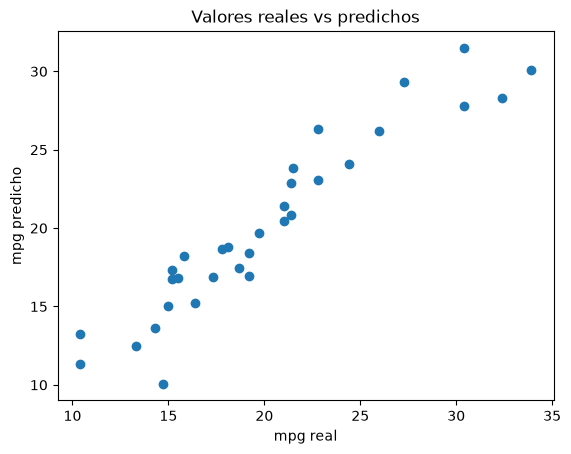

In [16]:
plt.scatter(y, y_pred)

plt.xlabel('mpg real')
plt.ylabel('mpg predicho')
plt.title('Valores reales vs predichos')

plt.show()

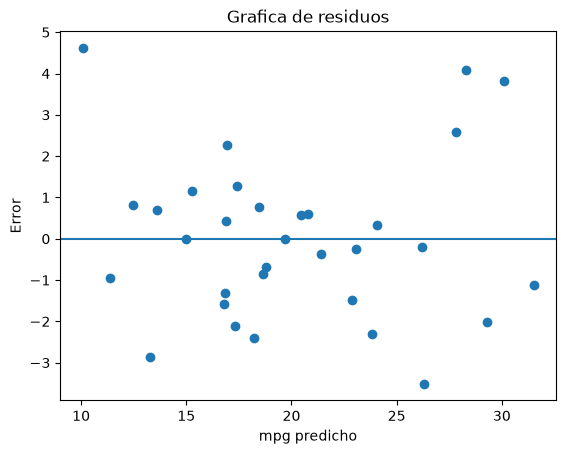

In [17]:
# Valores predichos
y_pred = pipeline.predict(X)

# Errores o residuos
error = y - y_pred

# Grafica de residuos
plt.scatter(y_pred, error)

plt.axhline(0)

plt.xlabel('mpg predicho')
plt.ylabel('Error')
plt.title('Grafica de residuos')

plt.show()

In [18]:
error

0    -3.797416e-01
1     5.693582e-01
2    -3.508729e+00
3     5.927215e-01
4     1.274199e+00
5    -6.854022e-01
6     6.908583e-01
7     3.402395e-01
8    -2.433036e-01
9     7.618855e-01
10   -8.588214e-01
11    1.149345e+00
12    4.356521e-01
13   -1.584997e+00
14   -2.856575e+00
15   -9.607132e-01
16    4.625051e+00
17    4.097123e+00
18   -1.109852e+00
19    3.819630e+00
20   -2.311083e+00
21   -1.316664e+00
22   -2.123523e+00
23    8.124625e-01
24    2.258668e+00
25   -2.004260e+00
26   -1.896166e-01
27    2.593380e+00
28   -2.403763e+00
29    3.552714e-15
30    3.552714e-15
31   -1.483528e+00
Name: mpg, dtype: float64

In [19]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score

loocv = LeaveOneOut()

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=loocv,
    scoring='neg_mean_squared_error',
    error_score='raise'  # Mostrar otros errores en lugar de devolver nan.
)

mse = -scores.mean()

mse

np.float64(23.08723223199287)

In [20]:
mse = -scores.mean()

mse

np.float64(23.08723223199287)

In [21]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kfold = KFold(n_splits=5, shuffle=True, random_state=15)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kfold,
    scoring='r2',
    error_score='raise'  # Mostrar otros errores en lugar de devolver nan.
)

scores

array([ 0.48064512, -3.32020235, -1.61866466,  0.73409105,  0.54962846])

In [22]:
scores.mean()

np.float64(-0.6349004762581916)

In [23]:
# Desviación estándar del MSE con Regresión Lineal y LOOCV
scores_linear = cross_val_score(
    pipeline,
    X,
    y,
    cv=loocv,
    scoring='neg_mean_squared_error',
    error_score='raise'
)

mse_linear_mean = (-scores_linear).mean()
mse_linear_std = (-scores_linear).std()

mse_linear_mean, mse_linear_std

(np.float64(23.08723223199287), np.float64(43.31325142775128))

In [24]:
# Modelo penalizado: Lasso con alpha de 0.01
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)

lasso_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', lasso_model)
    ]
)

scores_lasso = cross_val_score(
    lasso_pipeline,
    X,
    y,
    cv=loocv,
    scoring='neg_mean_squared_error',
    error_score='raise'
)

mse_lasso_mean = (-scores_lasso).mean()
mse_lasso_std = (-scores_lasso).std()

mse_lasso_mean, mse_lasso_std

(np.float64(16.436534782993842), np.float64(27.794699111288022))